In [1]:
import pandas as pd
import matplotlib.pyplot as plt

print("Setup successful")

Setup successful


In [4]:
import os
print(os.listdir())

['Nutrition,_Physical_Activity,_and_Obesity_-_American_Community_Survey_20260430.csv', 'analysis_new.ipynb', '.venv', '.ipynb_checkpoints']


In [24]:
df = pd.read_csv("Nutrition,_Physical_Activity,_and_Obesity_-_American_Community_Survey_20260430.csv")

df.head()

,YearStart,YearEnd,LocationAbbr,LocationDesc,Datasource,Class,Topic,Question,Data_Value_Unit,Data_Value_Type,...,GeoLocation,ClassID,TopicID,QuestionID,DataValueTypeID,LocationID,StratificationCategory1,Stratification1,StratificationCategoryId1,StratificationID1
0,2010,2010,AL,Alabama,American Community Survey,Physical Activity,Physical Activity - Behavior,Percent of adults in the state who usually bik...,NaN,Value,...,"(32.840571122, -86.631860762)",PA,PA1,Q042,VALUE,1,Total,Total,OVR,OVERALL
1,2010,2010,AK,Alaska,American Community Survey,Physical Activity,Physical Activity - Behavior,Percent of adults in the state who usually bik...,NaN,Value,...,"(64.845079957001, -147.722059036)",PA,PA1,Q042,VALUE,2,Total,Total,OVR,OVERALL
2,2010,2010,AZ,Arizona,American Community Survey,Physical Activity,Physical Activity - Behavior,Percent of adults in the state who usually bik...,NaN,Value,...,"(34.86597028, -111.763811277)",PA,PA1,Q042,VALUE,4,Total,Total,OVR,OVERALL
3,2010,2010,AR,Arkansas,American Community Survey,Physical Activity,Physical Activity - Behavior,Percent of adults in the state who usually bik...,NaN,Value,...,"(34.748650124, -92.274490743)",PA,PA1,Q042,VALUE,5,Total,Total,OVR,OVERALL
4,2010,2010,CA,California,American Community Survey,Physical Activity,Physical Activity - Behavior,Percent of adults in the state who usually bik...,NaN,Value,...,"(37.638640123, -120.999999538)",PA,PA1,Q042,VALUE,6,Total,Total,OVR,OVERALL


In [25]:
print(df.shape)
print(df.columns)

(770, 27)
Index(['YearStart', 'YearEnd', 'LocationAbbr', 'LocationDesc', 'Datasource',
       'Class', 'Topic', 'Question', 'Data_Value_Unit', 'Data_Value_Type',
       'Data_Value', 'Data_Value_Alt', 'Data_Value_Footnote_Symbol',
       'Data_Value_Footnote', 'Low_Confidence_Limit', 'High_Confidence_Limit ',
       'Total', 'GeoLocation', 'ClassID', 'TopicID', 'QuestionID',
       'DataValueTypeID', 'LocationID', 'StratificationCategory1',
       'Stratification1', 'StratificationCategoryId1', 'StratificationID1'],
      dtype='str')


In [26]:
df_clean = df[['LocationDesc', 'YearStart', 'Data_Value']]

df_clean.columns = ['state', 'year', 'value']

df_clean.head()

,state,year,value
0,Alabama,2010,1.4
1,Alaska,2010,9.2
2,Arizona,2010,2.9
3,Arkansas,2010,1.9
4,California,2010,3.7


In [27]:
df_clean = df_clean.dropna()

df_clean['year'] = df_clean['year'].astype(int)
df_clean['value'] = df_clean['value'].astype(float)

df_clean.head()

,state,year,value
0,Alabama,2010,1.4
1,Alaska,2010,9.2
2,Arizona,2010,2.9
3,Arkansas,2010,1.9
4,California,2010,3.7


In [28]:
df_year = df_clean.groupby('year')['value'].mean().reset_index()

df_year

,year,value
0,2010,3.732075
1,2011,3.750943
2,2012,3.837736
3,2013,3.892453
4,2014,3.762264
5,2015,3.805660
6,2016,3.724528
7,2017,3.620755
8,2018,3.549057
9,2019,3.501887


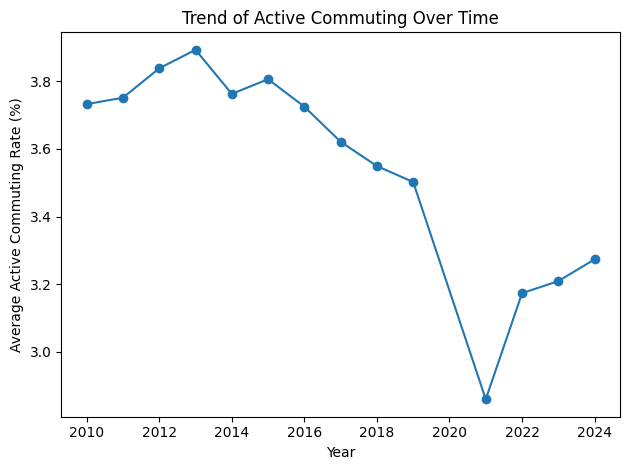

In [29]:
plt.figure()

plt.plot(df_year['year'], df_year['value'], marker='o')

plt.xlabel("Year")
plt.ylabel("Average Active Commuting Rate (%)")
plt.title("Trend of Active Commuting Over Time")

plt.tight_layout()
plt.show()

In [30]:
df_state = df_clean.groupby('state')['value'].mean().reset_index()

df_state.head()

,state,value
0,Alabama,1.257143
1,Alaska,8.435714
2,Arizona,2.692857
3,Arkansas,1.821429
4,California,3.535714


In [31]:
top_states = df_state.sort_values(by='value', ascending=False).head()

top_states

,state,value
8,District of Columbia,15.792857
1,Alaska,8.435714
33,New York,6.792857
47,Vermont,6.042857
26,Montana,5.964286


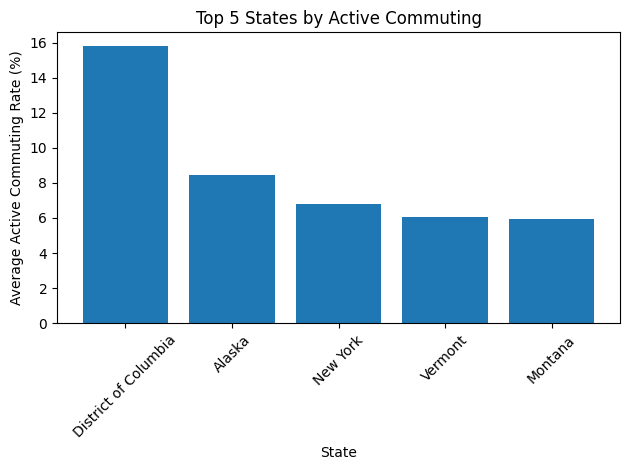

In [32]:
plt.figure()

plt.bar(top_states['state'], top_states['value'])

plt.xlabel("State")
plt.ylabel("Average Active Commuting Rate (%)")
plt.title("Top 5 States by Active Commuting")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [33]:
bottom_states = df_state.sort_values(by='value').head()

bottom_states

,state,value
0,Alabama,1.257143
44,Tennessee,1.407143
24,Mississippi,1.528571
10,Georgia,1.685714
45,Texas,1.792857


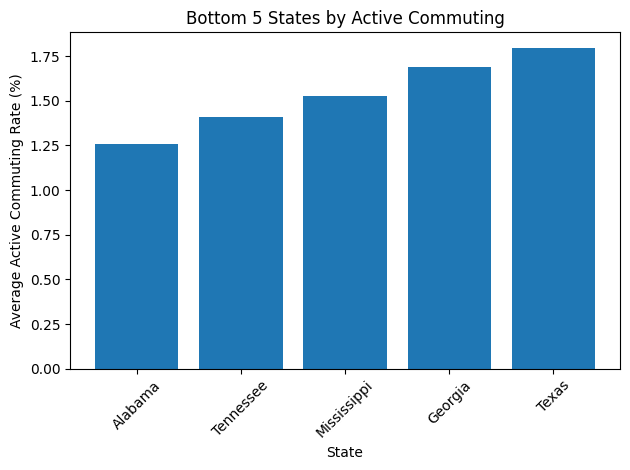

In [34]:
plt.figure()

plt.bar(bottom_states['state'], bottom_states['value'])

plt.xlabel("State")
plt.ylabel("Average Active Commuting Rate (%)")
plt.title("Bottom 5 States by Active Commuting")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Conclusion

This analysis examined active commuting rates across U.S. states using CDC data.

The results show that active commuting varies by state. The District of Columbia, Alaska, and New York had higher average active commuting rates, while Alabama, Tennessee, and Mississippi had lower rates.

The trend over time shows a decline around 2020-2021, followed by a slight recovery in recent years.

This project demonstrates how Python, Pandas, and Matplotlib can be used to clean, analyze, and visualize public health data.
    